# 10강 · 측정부터 분석까지

**8월 17일 (월) 수업**

자기장 데이터를 읽고, 거리에 따라 얼마나 약해지는지 찾습니다.

---

**먼저 상단 `Drive로 복사`를 누르세요.** 그래야 실행됩니다.

셀은 **위에서부터 차례대로** 실행합니다. 실행은 **Shift + Enter**.

## 1단계 · 준비

도구를 불러옵니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("준비 완료")

준비 완료


## 2단계 · 데이터 불러오기

8cm 데이터를 읽습니다.

In [2]:
url = "https://lhc0312.github.io/arduino-class/data/mag_8cm_all.csv"
df = pd.read_csv(url)

df.head()

,magnet,cell_i,cell_j,sample,t_s,x_mm,y_mm,z_mm,Bx_uT,By_uT,...,Babs_uT,Bbx_uT,Bby_uT,Bbz_uT,ax_g,ay_g,az_g,tilt_deg,gain_idx,qmc
0,m1,0,0,1,0.030,-40.0,40.0,0.0,92.2563,-285.3922,...,410.8491,-45.3200,-49.0933,-405.3800,-1.83089,-2.80098,-2.24847,123.898,4,1
1,m1,0,0,2,0.253,-40.0,40.0,0.0,95.2864,-283.7281,...,410.5566,-41.6867,-49.8600,-405.3800,-1.80525,-2.77717,-2.24786,124.162,4,1
2,m1,0,0,3,0.463,-40.0,40.0,0.0,91.2201,-287.8159,...,411.6746,-46.1867,-46.5933,-406.4133,-1.83150,-2.79365,-2.24176,123.865,4,1
3,m1,0,0,4,0.673,-40.0,40.0,0.0,92.5888,-288.5675,...,412.2792,-43.4867,-46.0933,-407.3800,-1.81685,-2.80037,-2.25214,124.007,4,1
4,m1,0,0,5,0.883,-40.0,40.0,0.0,89.7762,-286.8330,...,413.8311,-48.8867,-48.0600,-408.1133,-1.82112,-2.78327,-2.25519,124.138,4,1


## 3단계 · 크기 확인

몇 줄이 들어왔는지 확인합니다.

In [3]:
print("행 수 :", len(df))
print("자석  :", sorted(df["magnet"].unique()))
print("열    :", list(df.columns[:8]), "...")

행 수 : 450
자석  : ['m1', 'm3', 'm4', 'm7', 'm9']
열    : ['magnet', 'cell_i', 'cell_j', 'sample', 't_s', 'x_mm', 'y_mm', 'z_mm'] ...


450줄 = **자석 5개 × 칸 9개 × 반복 10번**.

한 칸당 10줄이므로 대표값 하나로 줄입니다.

## 4단계 · 10번 잰 것을 하나로

**중앙값**으로 줄입니다. 한 번 튄 값에 끌려가지 않습니다.

자기장은 `Bbx / Bby / Bbz` (센서 기준) 를 씁니다.

In [4]:
cell = (df.groupby(["magnet", "cell_i", "cell_j"])
          .agg(x_mm=("x_mm", "first"),
               y_mm=("y_mm", "first"),
               Bx=("Bbx_uT", "median"),
               By=("Bby_uT", "median"),
               Bz=("Bbz_uT", "median"))
          .reset_index())

print(len(cell), "줄로 줄었습니다")
cell.head()

45 줄로 줄었습니다


,magnet,cell_i,cell_j,x_mm,y_mm,Bx,By,Bz
0,m1,0,0,-40.0,40.0,-43.97000,-49.61000,-407.63000
1,m1,0,1,-40.0,0.0,-223.45335,-45.73085,-200.47165
2,m1,0,2,-40.0,-40.0,-149.05335,-22.73500,-48.56335
3,m1,1,0,0.0,40.0,-35.82000,113.75665,-335.09665
4,m1,1,1,0.0,0.0,-186.83670,75.95250,-183.64665


## 5단계 · 자기장 세기 구하기

세 축을 하나로 합칩니다.

In [5]:
cell["B"] = np.sqrt(cell["Bx"]**2 + cell["By"]**2 + cell["Bz"]**2)

cell[["magnet", "x_mm", "y_mm", "B"]].head()

,magnet,x_mm,y_mm,B
0,m1,-40.0,40.0,412.985145
1,m1,-40.0,0.0,303.663618
2,m1,-40.0,-40.0,158.405115
3,m1,0.0,40.0,355.687240
4,m1,0.0,0.0,272.768816


## 6단계 · 자석까지의 거리 구하기

`m1` `m3` … 이 자석을 놓은 칸입니다. 그 좌표로 거리를 계산합니다.

**`DEPTH` 에 자로 잰 값을 넣으세요.**

In [6]:
POS = {"m1": (-40,  40), "m2": (0,  40), "m3": (40,  40),
       "m4": (-40,   0), "m5": (0,   0), "m6": (40,   0),
       "m7": (-40, -40), "m8": (0, -40), "m9": (40, -40)}

DEPTH = 80.0        # 센서 판과 자석 사이 수직거리 (mm) = 8 cm

cell["mx"] = cell["magnet"].map(lambda m: POS[m][0])
cell["my"] = cell["magnet"].map(lambda m: POS[m][1])

cell["r"] = np.sqrt((cell["x_mm"] - cell["mx"])**2
                  + (cell["y_mm"] - cell["my"])**2
                  + DEPTH**2)

print(f"거리 범위 : {cell['r'].min():.0f} ~ {cell['r'].max():.0f} mm")
print(f"세기 범위 : {cell['B'].min():.0f} ~ {cell['B'].max():.0f} uT")

거리 범위 : 80 ~ 139 mm
세기 범위 : 67 ~ 419 uT


자석 바로 위 80mm, 대각선 끝 139mm.

9칸을 훑으므로 거리 9가지가 한 번에 생깁니다.

## 7단계 · 그림으로 보기

계산 전에 그림으로 확인합니다.

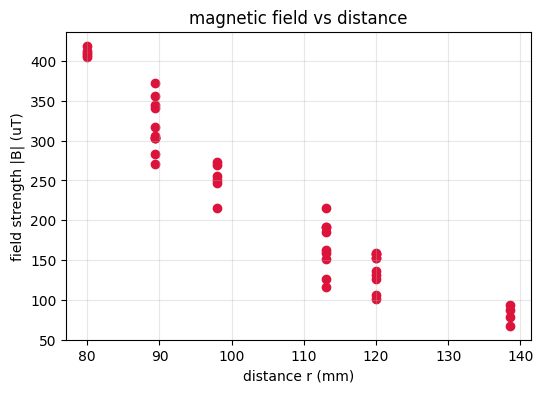

In [7]:
plt.figure(figsize=(6, 4))
plt.scatter(cell["r"], cell["B"], color="crimson")

plt.xlabel("distance r (mm)")
plt.ylabel("field strength |B| (uT)")
plt.title("magnetic field vs distance")
plt.grid(alpha=0.3)
plt.show()

멀어질수록 급격히 작아지는 곡선입니다.

---

## 8단계 · 오늘의 질문

> **자기장은 거리가 멀어질 때 얼마나 빨리 약해질까?**

이렇게 생겼다고 가정합니다.

$$|B| = \frac{k}{r^{\,n}}$$

- `r` = 자석까지 거리
- `k` = 자석의 세기 (상수)
- `n` = **거리 지수** ← 이걸 찾는 것

`n` 을 1부터 5까지 넣어 보고 가장 잘 맞는 값을 고릅니다.

## 9단계 · 로그를 씌워 직선으로

양변에 로그를 씌우면 직선이 됩니다.

```
    |B| = k / r^n

log|B| = log k  -  n · log r
   ↑                ↑     ↑
   y    =    절편  -  n ·  x      ← 직선!
```

**기울기가 곧 −n** 입니다.

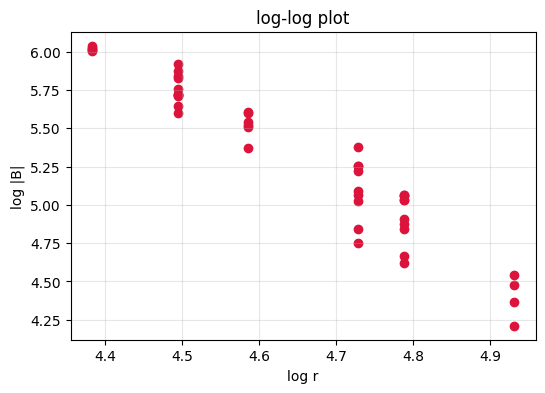

In [8]:
cell["log_r"] = np.log(cell["r"])
cell["log_B"] = np.log(cell["B"])

plt.figure(figsize=(6, 4))
plt.scatter(cell["log_r"], cell["log_B"], color="crimson")

plt.xlabel("log r")
plt.ylabel("log |B|")
plt.title("log-log plot")
plt.grid(alpha=0.3)
plt.show()

점들이 직선에 가깝습니다. `k / r^n` 가정이 맞습니다.

## 10단계 · n = 1~5 를 하나씩 넣어보기

`n` 을 고정하고 `k` 만 맞춘 뒤 잔차를 잽니다.

**잔차가 작을수록 잘 맞습니다.**

In [9]:
r = cell["r"].to_numpy()
B = cell["B"].to_numpy()

for n in [1, 2, 3, 4, 5]:
    k = np.exp(np.mean(np.log(B) + n*np.log(r)))   # n 을 고정했을 때 최적의 k
    pred = k / r**n
    err = np.sqrt(np.mean((np.log(pred) - np.log(B))**2))
    print(f"n = {n}   잔차 = {err:.4f}")

n = 1   잔차 = 0.3409
n = 2   잔차 = 0.2016
n = 3   잔차 = 0.1379
n = 4   잔차 = 0.2265
n = 5   잔차 = 0.3709


**n = 3 일 때 잔차가 가장 작습니다.**

## 11단계 · 그림으로 확인

세 곡선을 겹쳐 그립니다.

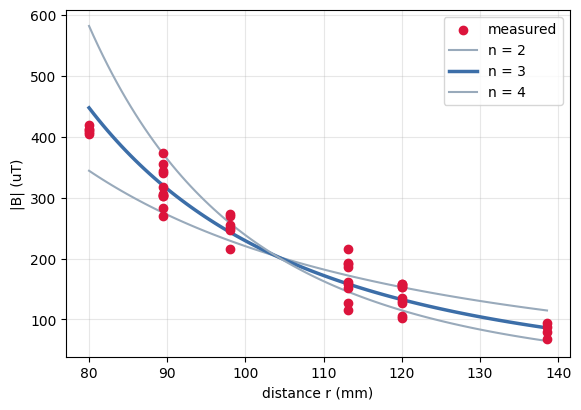

In [10]:
plt.figure(figsize=(6.5, 4.5))
plt.scatter(r, B, color="crimson", zorder=3, label="measured")

rr = np.linspace(r.min(), r.max(), 100)
for n, c in [(2, "#9ab"), (3, "#3c6ea8"), (4, "#9ab")]:
    k = np.exp(np.mean(np.log(B) + n*np.log(r)))
    plt.plot(rr, k/rr**n, color=c, lw=2.5 if n == 3 else 1.5,
             label=f"n = {n}")

plt.xlabel("distance r (mm)")
plt.ylabel("|B| (uT)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 12단계 · n 을 자유롭게 풀어보기

소수까지 찾습니다.

In [11]:
a, b = np.polyfit(cell["log_r"], cell["log_B"], 1)

pred = np.polyval([a, b], cell["log_r"])
r2 = 1 - np.sum((pred - cell["log_B"])**2) / np.sum((cell["log_B"] - cell["log_B"].mean())**2)

print(f"기울기 = {a:.2f}")
print(f"n      = {-a:.2f}")
print(f"R2     = {r2:.4f}")

기울기 = -2.90
n      = 2.90
R2     = 0.9237


---

## 13단계 · 왜 3일까

자석은 **N극과 S극이 한 쌍**으로만 존재합니다.

| 만약 | 거리 의존성 |
|---|---|
| 극이 **하나**뿐이라면 | 1 / r² |
| 극이 **쌍**이라 서로 상쇄되면 | **1 / r³** |

두 극이 반대라 멀리서 대부분 상쇄됩니다. 그래서 **1/r² 이 1/r³ 으로** 한 단계 더 빨리 약해집니다.

**n = 3 입니다.**

## 14단계 · 그런데 2.90 이 나왔습니다

이론 3.00, 측정 2.90. 차이 0.10.

| 가능성 | 내용 | 방향 |
|---|---|---|
| **배경이 남음** | 배경 보정이 덜 되면 멀리서 값이 덜 떨어짐 | n 작아짐 |
| **거리 재기 오차** | `DEPTH` 를 실제와 다르게 잡음 | 양쪽 다 |
| **자석 크기** | 자석이 점이 아니라 크기가 있음 | n 커짐 |
| **측정 잡음** | 45점으로는 ±0.1 정도 흔함 | 양쪽 다 |

`DEPTH` 를 바꿔가며 확인합니다.

In [12]:
for d in [70, 75, 80, 85, 90, 100]:
    rr = np.sqrt((cell["x_mm"] - cell["mx"])**2
               + (cell["y_mm"] - cell["my"])**2 + d**2)
    n = -np.polyfit(np.log(rr), np.log(cell["B"]), 1)[0]
    print(f"DEPTH = {d:3d} mm  ->  n = {n:.2f}")

DEPTH =  70 mm  ->  n = 2.47
DEPTH =  75 mm  ->  n = 2.68
DEPTH =  80 mm  ->  n = 2.90
DEPTH =  85 mm  ->  n = 3.13
DEPTH =  90 mm  ->  n = 3.37
DEPTH = 100 mm  ->  n = 3.89


거리 10mm 오차가 지수를 0.2 이상 바꿉니다.

**자로 정확히 재세요.**

---

## 15단계 · 내가 잰 데이터로 바꾸기

오늘 측정한 파일로 같은 분석을 합니다.

아래 셀을 실행하면 파일 선택 창이 뜹니다.

In [13]:
# 오늘 측정한 파일이 있으면 주석을 풀고 실행하세요.
#
# from google.colab import files
# up = files.upload()
#
# my = pd.read_csv(list(up.keys())[0])
# print(len(my), "줄")
# my.head()
print("파일을 올릴 준비가 되면 위 주석을 푸세요.")

파일을 올릴 준비가 되면 위 주석을 푸세요.


### 여러 파일을 한 번에 읽기

파일 이름에서 `m1` `m3` … 을 뽑아 `magnet` 열을 만듭니다.

In [14]:
# import re, glob
#
# frames = []
# for path in sorted(glob.glob("*.csv")):
#     tag = re.search(r"_(m\d)\.csv$", path)
#     if not tag:
#         continue
#     one = pd.read_csv(path)
#     one["magnet"] = tag.group(1)
#     frames.append(one)
#
# mine = pd.concat(frames, ignore_index=True)
# print(len(mine), "줄,", sorted(mine["magnet"].unique()))
print("여러 파일을 올렸다면 위 주석을 푸세요.")

여러 파일을 올렸다면 위 주석을 푸세요.


---

## 오늘 한 일

1. CSV 를 읽고 450줄을 확인
2. 중앙값으로 45줄로 축약
3. 세 축을 합쳐 세기 계산
4. 자석까지의 거리 계산
5. 로그를 씌워 직선으로 변환
6. n = 1~5 를 비교해 **n = 3** 확인
7. 왜 3인지 설명